In [ ]:
!hostname
!echo $HF_HOME

In [ ]:
from diffusers import SanaPipeline, DPMSolverMultistepScheduler, AutoencoderDC, SanaTransformer2DModel
import torch
from transformers import Gemma2PreTrainedModel, Gemma2Model, GemmaTokenizerFast
import numpy as np
from typing import Union,List


In [4]:
pipeline = SanaPipeline.from_pretrained("Efficient-Large-Model/SANA_Sprint_0.6B_1024px_teacher_diffusers")
pipeline.to('cuda')

noise_scheduler: DPMSolverMultistepScheduler = pipeline.scheduler
tokenizer: GemmaTokenizerFast = pipeline.tokenizer
vae: AutoencoderDC = pipeline.vae
text_encoder: Gemma2Model = pipeline.text_encoder
transformer_teacher: SanaTransformer2DModel = pipeline.transformer

transformer_teacher.requires_grad_(False)
vae.requires_grad_(False)
text_encoder.requires_grad_(False)

Loading pipeline components...: 100%|██████████| 5/5 [00:02<00:00,  1.93it/s]


Gemma2Model(
  (embed_tokens): Embedding(256000, 2304, padding_idx=0)
  (layers): ModuleList(
    (0-25): 26 x Gemma2DecoderLayer(
      (self_attn): Gemma2Attention(
        (q_proj): Linear(in_features=2304, out_features=2048, bias=False)
        (k_proj): Linear(in_features=2304, out_features=1024, bias=False)
        (v_proj): Linear(in_features=2304, out_features=1024, bias=False)
        (o_proj): Linear(in_features=2048, out_features=2304, bias=False)
      )
      (mlp): Gemma2MLP(
        (gate_proj): Linear(in_features=2304, out_features=9216, bias=False)
        (up_proj): Linear(in_features=2304, out_features=9216, bias=False)
        (down_proj): Linear(in_features=9216, out_features=2304, bias=False)
        (act_fn): PytorchGELUTanh()
      )
      (input_layernorm): Gemma2RMSNorm((2304,), eps=1e-06)
      (post_attention_layernorm): Gemma2RMSNorm((2304,), eps=1e-06)
      (pre_feedforward_layernorm): Gemma2RMSNorm((2304,), eps=1e-06)
      (post_feedforward_layernorm): 

In [6]:
from src.esd_meta_sana import data_loader
from types import SimpleNamespace

args = SimpleNamespace(resolution=1024, center_crop=False, random_flip=False, train_batch_size=1, guidance_scale=4.5)
(
    hrm_train_dataloader,
    hrm_test_dataloader,
    irt_train_dataloader,
    irt_test_dataloader,
    tgt_train_dataloader,
    tgt_test_dataloader,
) = data_loader(args, pipeline.tokenizer)

for batch in irt_train_dataloader:
    break

In [7]:
with torch.no_grad():
    
    latents = vae.encode(batch['pixel_values'].to('cuda'))['latent']
    latents = latents * vae.config['scaling_factor']

    noise = torch.randn_like(latents)

    bsz = latents.shape[0]

    # Prepare timesteps
    num_inference_steps = 20
    noise_scheduler.set_timesteps(num_inference_steps, device=vae.device)
    timesteps = torch.randint(0, num_inference_steps, (bsz,), device=latents.device)
    timesteps = timesteps * transformer_teacher.config.timestep_scale
    # timesteps = noise_scheduler.timesteps[idx]
    # timesteps = torch.randint(0, noise_scheduler.config['num_train_timesteps'], (bsz,), device=latents.device).long()

    noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

    encoder_hidden_states = text_encoder(batch['input_ids'].to('cuda'), return_dict=False)[0]

    target = noise - latents

    x = transformer_teacher(
        noisy_latents,
        encoder_hidden_states=encoder_hidden_states,
        timestep=timesteps,
        return_dict=False,
    )[0]

In [8]:
from src.esd_meta_sana import sample_until, encode_prompt

with torch.no_grad():
    prompt_embeds, prompt_attention_mask = encode_prompt(
        prompt="woman", 
        removing_prompt='nudity',
        text_encoder=text_encoder, 
        tokenizer=tokenizer,
        device='cuda',
    )
    uncond_emb, cond_emb, safety_emb = torch.chunk(prompt_embeds, 3, dim=0)
    uncond_attn_mask, cond_attn_mask, safety_attn_mask = torch.chunk(prompt_attention_mask, 3, dim=0)

    prompt_embeds = torch.cat([uncond_emb, cond_emb], dim=0) if args.guidance_scale > 1.0 else uncond_emb
    prompt_embeds = prompt_embeds.to('cuda')
    prompt_attention_mask = torch.cat([uncond_attn_mask, cond_attn_mask], dim=0) if args.guidance_scale > 1.0 else uncond_emb
    prompt_attention_mask = prompt_attention_mask.to('cuda')

    x0_halfway = sample_until(
        until=20,
        latents=noise,
        transformer=transformer_teacher,
        scheduler=noise_scheduler,
        prompt_embeds=prompt_embeds,
        prompt_attention_mask=prompt_attention_mask,
        num_inference_steps=20,
        guidance_scale=4.5,
        extra_step_kwargs={},
    )

    decoded_x0_halfway = vae.decode(x0_halfway / vae.config['scaling_factor'])['sample']

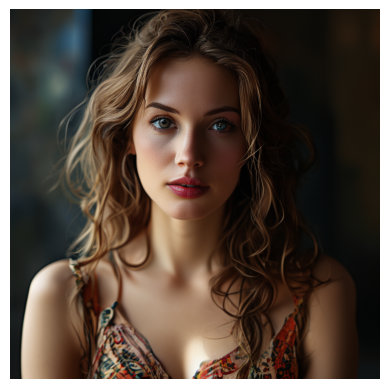

In [9]:

import torchvision.transforms as T
import matplotlib.pyplot as plt

# The decoded tensor is expected to be a batch: (B, C, H, W)
# Convert it to the appropriate range and type for display
to_pil = T.ToPILImage()

# Take the first image in the batch (if batched)
# img = batch['pixel_values'][0].cpu().clamp(-1, 1)  # Clamp if output is in [-1,1]; adjust if needed
# img = decoded_noisy_latent[0].cpu().clamp(-1, 1)  # Clamp if output is in [-1,1]; adjust if needed
# img = decoded[0].cpu().clamp(-1, 1)  # Clamp if output is in [-1,1]; adjust if needed
img = decoded_x0_halfway[0].cpu().clamp(-1, 1)  # Clamp if output is in [-1,1]; adjust if needed
# img = decoded_lol[0].cpu().clamp(-1, 1)  # Clamp if output is in [-1,1]; adjust if needed

# If needed, shift/scale appropriately (e.g., if in [-1,1], to [0,1])
img = (img + 1.0) / 2.0
img = img.clamp(0, 1)

plt.imshow(to_pil(img))
plt.axis('off')
plt.show()

# decoded

In [91]:
res_pipe = pipeline(
    # 'woman',
    # negative_prompt='nudity',
    # latents=noise,
    prompt_embeds=cond_emb,
    prompt_attention_mask=cond_attn_mask,
    # negative_prompt=uncond_emb,
    # negative_prompt_attention_mask=uncond_attn_mask,
    output_type='latent',
).images[0]

 10%|█         | 2/20 [00:00<00:01, 17.37it/s]

100%|██████████| 20/20 [00:01<00:00, 13.87it/s]


In [ ]:
decoded_pipe = vae.decode(res_pipe.unsqueeze(0) / vae.config['scaling_factor'])['sample']
pipeline.image_processor.postprocess(decoded_pipe, output_type='pil')[0]

In [12]:
latents.std()

tensor(0.9911, device='cuda:0')

In [10]:
x.std()

tensor(0.8487, device='cuda:0')

In [13]:
(x - target).std()

tensor(1.0843, device='cuda:0')

In [ ]:
(x - noise).std()

tensor(1.0730, device='cuda:0')

In [ ]:
x.std()

tensor(0.3793, device='cuda:0')

In [16]:
(x - noise).std()

tensor(1.0730, device='cuda:0')

In [18]:
(x - target).std()

tensor(1.4306, device='cuda:0')

In [17]:
noise_scheduler.sigmas

tensor([0.9997, 0.9824, 0.9639, 0.9441, 0.9227, 0.8996, 0.8746, 0.8475, 0.8178,
        0.7853, 0.7496, 0.7102, 0.6663, 0.6173, 0.5621, 0.4997, 0.4283, 0.3459,
        0.2498, 0.1362, 0.0000])

In [19]:
timesteps

tensor([8], device='cuda:0')

In [22]:
timesteps

tensor([0.0050], device='cuda:0')

In [ ]:
# Compare to scheduler.step() output
with torch.no_grad():
    noise_scheduler.set_timesteps(20)
    decoded_via_scheduler = noise_scheduler.step(
        x,
        timestep=int(timesteps.item() * 1000),
        sample=noisy_latents,
    ).prev_sample

    decoded_via_scheduler = vae.decode(decoded_via_scheduler / vae.config['scaling_factor'])['sample']


In [54]:
noisy_latents.std()

tensor(1.7672, device='cuda:0')

In [51]:
x.shape

torch.Size([1, 32, 32, 32])

In [35]:
timesteps

tensor([638], device='cuda:0')

In [31]:
latents.shape

torch.Size([1, 32, 32, 32])

In [28]:
vae.config['scaling_factor']

0.41407

In [10]:
latents['latent'].shape

torch.Size([1, 32, 32, 32])